--- PROJECT 4 SUCCESSFUL ---

Compliance Metrics Breakdowns (%):
Regulatory_Status
ADULTERATED (FAIL)    53.3
SAFE (PASS)           46.7
Name: proportion, dtype: float64


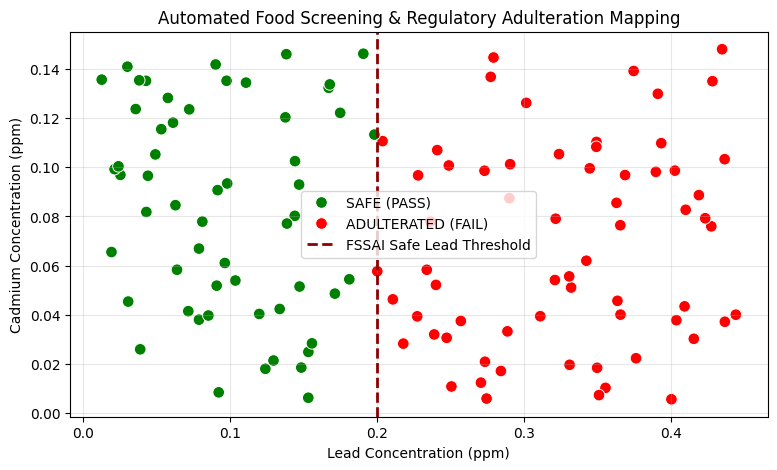

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulate laboratory food sample test parameters (Lead and Cadmium metrics)
np.random.seed(42)
samples_count = 120

lead_ppm = np.random.uniform(0.01, 0.45, samples_count)
cadmium_ppm = np.random.uniform(0.005, 0.15, samples_count)

df = pd.DataFrame({'Lead_ppm': lead_ppm, 'Cadmium_ppm': cadmium_ppm})

# 2. Set regulatory compliance masks (e.g., FSSAI max safe threshold for Lead = 0.2 ppm)
FSSAI_LEAD_LIMIT = 0.20

def evaluate_safety(row):
    if row['Lead_ppm'] > FSSAI_LEAD_LIMIT:
        return 'ADULTERATED (FAIL)'
    return 'SAFE (PASS)'

df['Regulatory_Status'] = df.apply(evaluate_safety, axis=1)

# 3. Print analysis matrices
fail_percentage = (df['Regulatory_Status'].value_counts(normalize=True) * 100).round(1)
print("--- PROJECT 4 SUCCESSFUL ---")
print("\nCompliance Metrics Breakdowns (%):")
print(fail_percentage)

# 4. Generate the screening plot
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Lead_ppm', y='Cadmium_ppm', hue='Regulatory_Status', palette={'SAFE (PASS)': 'green', 'ADULTERATED (FAIL)': 'red'}, s=70)
plt.axvline(x=FSSAI_LEAD_LIMIT, color='darkred', linestyle='--', linewidth=2, label='FSSAI Safe Lead Threshold')
plt.title('Automated Food Screening & Regulatory Adulteration Mapping')
plt.xlabel('Lead Concentration (ppm)')
plt.ylabel('Cadmium Concentration (ppm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
